In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

### Part (a)

Temperature array dimensions: (1000, 2001)
Salinity array dimensions: (1000, 2001)


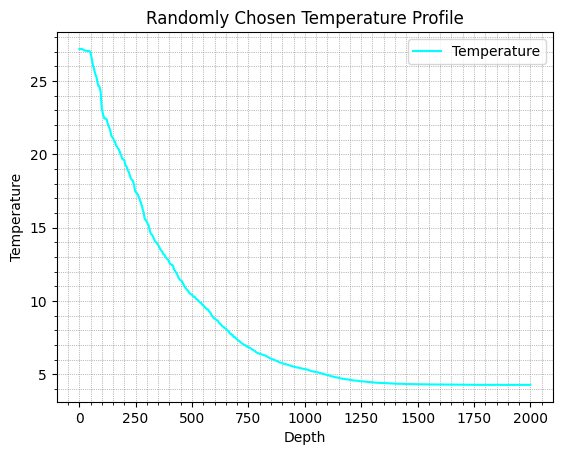

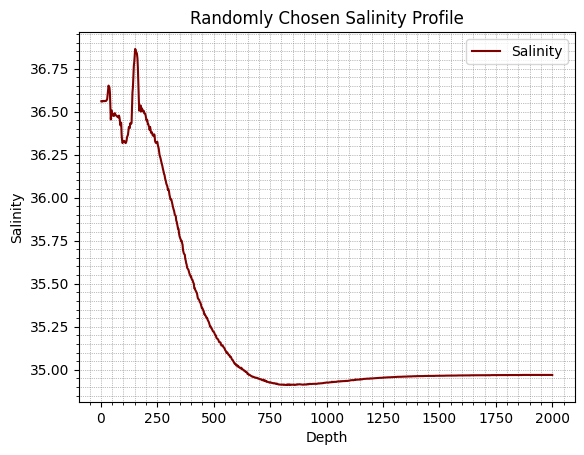

In [3]:
# Open the .mat file
file_name = "profiles.mat"
with h5py.File(file_name, 'r') as f:
    # Access relevant data (equivalent to MATLAB variables)
    temperature = f['TEMP'][()]
    salinity = f['SAL'][()]

# Print the dimensions of the arrays
print("Temperature array dimensions:", temperature.shape)
print("Salinity array dimensions:", salinity.shape)

# Plot a randomly chosen temperature profile
random_index_temp = np.random.randint(0, temperature.shape[0])
plt.plot(temperature[random_index_temp], label='Temperature', color='cyan')
plt.xlabel('Depth')
plt.ylabel('Temperature')
plt.title('Randomly Chosen Temperature Profile')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()

# Plot a randomly chosen salinity profile
random_index_sal = np.random.randint(0, salinity.shape[0])
plt.plot(salinity[random_index_sal], label='Salinity', color='maroon')
plt.xlabel('Depth')
plt.ylabel('Salinity')
plt.title('Randomly Chosen Salinity Profile')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.legend()
plt.show()


Reduced Temperature array dimensions: (1000, 2001)
Reduced Salinity array dimensions: (1000, 2001)


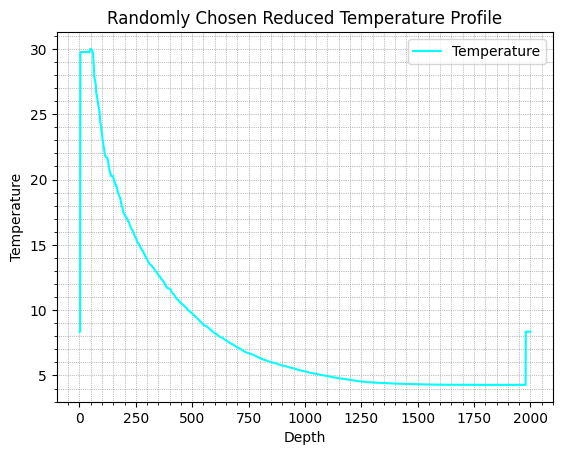

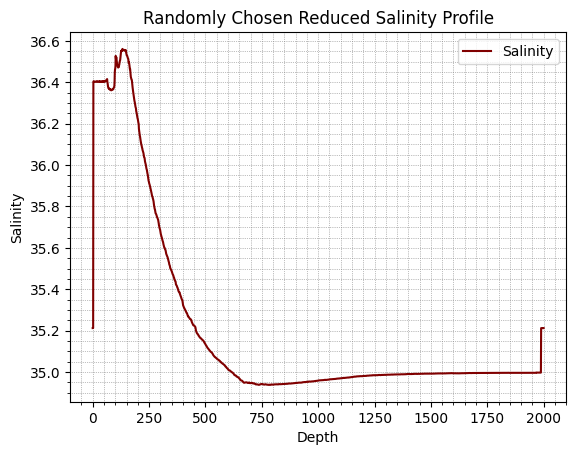

In [7]:
# defining function for SVD approximation
def SVD_approximation(matrix, rank):
    '''--------------------------------------------------------------
    The function performs SVD decomposition of image matrix and then
    gives approximation of the matrix A for a given rank
    
    PARMAETER
    - image_matrix (numpy.ndarray) : matrix containing image data
    - rank (int) : the rank upto which A is to be approximated
    
    RETURNS
    A_approx (numpy.ndarray) - An approximation of image_matrix 
    -----------------------------------------------------------------'''
    
    # performing SVD for image_matrix
    U, S, V_T = np.linalg.svd(matrix, full_matrices=False)
    
    # Ensuring that the rank does not exceed the number of eigenvalues
    rank = min(rank, min(matrix.shape))
    
    A_approx = U[:, :rank] @ np.diag(S[:rank]) @ V_T[:rank, :]
        
    return A_approx 

# Handle NaN and inf values by replacing them with the mean of the profile
def replace_nan_inf(data):
    # Replace inf with NaN to handle them together
    data[np.isinf(data)] = np.nan
    # Get the mean of each profile ignoring NaNs
    means = np.nanmean(data, axis=1)
    # Replace NaNs with the mean of the corresponding profile
    inds = np.where(np.isnan(data))
    data[inds] = np.take(means, inds[0])
    return data

temperature = replace_nan_inf(temperature)
salinity = replace_nan_inf(salinity)
temp_reduced = SVD_approximation(temperature, 400)
sal_reduced = SVD_approximation(salinity, 400)
# Print the dimensions of the reduced arrays
print("Reduced Temperature array dimensions:", temp_reduced.shape)
print("Reduced Salinity array dimensions:", sal_reduced.shape)

# Plot a randomly chosen reduced temperature profile
random_index_temp = np.random.randint(0, temp_reduced.shape[0])
plt.plot(temp_reduced[random_index_temp], label='Temperature', color='cyan')
plt.xlabel('Depth')
plt.ylabel('Temperature')
plt.title('Randomly Chosen Reduced Temperature Profile')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()

# Plot a randomly chosen reduced salinity profile
random_index_sal = np.random.randint(0, sal_reduced.shape[0])
plt.plot(sal_reduced[random_index_sal], label='Salinity', color='maroon')
plt.xlabel('Depth')
plt.ylabel('Salinity')
plt.title('Randomly Chosen Reduced Salinity Profile')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.legend()
plt.show()

### Part (b)

Temperature array dimensions: (1000, 2001)
Salinity array dimensions: (1000, 2001)
Reduced Temperature array dimensions: (1000, 2001)
Reduced Salinity array dimensions: (1000, 2001)


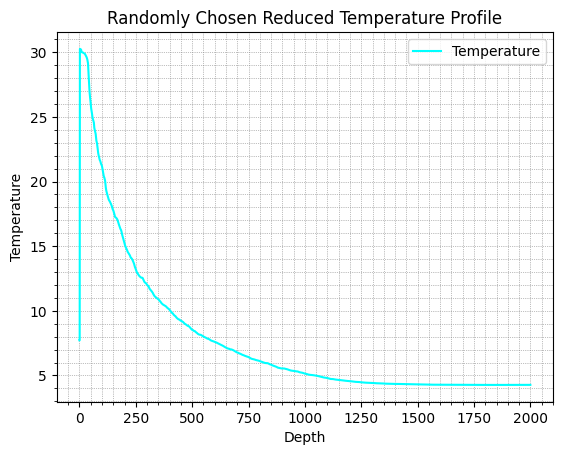

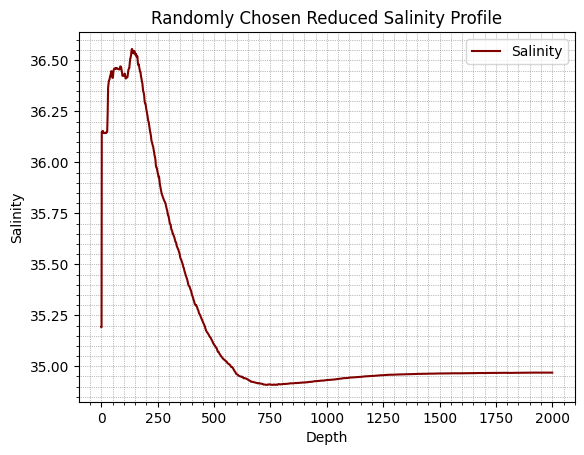

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from numpy import linalg

# Open the .mat file
file_name = "profiles.mat"
with h5py.File(file_name, 'r') as f:
    # Access relevant data (equivalent to MATLAB variables)
    temperature = f['TEMP'][()]
    salinity = f['SAL'][()]

# Print the dimensions of the arrays
print("Temperature array dimensions:", temperature.shape)
print("Salinity array dimensions:", salinity.shape)

# Handle NaN and inf values by replacing them with the mean of the profile
def replace_nan_inf(data):
    # Replace inf with NaN to handle them together
    data[np.isinf(data)] = np.nan
    # Get the mean of each profile ignoring NaNs
    means = np.nanmean(data, axis=1)
    # Replace NaNs with the mean of the corresponding profile
    inds = np.where(np.isnan(data))
    data[inds] = np.take(means, inds[0])
    return data

temperature = replace_nan_inf(temperature)
salinity = replace_nan_inf(salinity)

# Function to perform SVD and reduce dimensions
def reduce_dimensionality_svd(data, target_dim):
    U, S, VT = linalg.svd(data, full_matrices=False)
    # Keep only the top 'target_dim' singular values and vectors
    U_reduced = U[:, :target_dim]
    S_reduced = S[:target_dim]
    VT_reduced = VT[:target_dim, :]
    # Reconstruct the reduced data
    reduced_data = np.dot(U_reduced, np.diag(S_reduced) @ VT_reduced)
    return reduced_data

# Perform dimensionality reduction to (profiles, 400)
target_dim = 400
temperature_reduced = reduce_dimensionality_svd(temperature, target_dim)
salinity_reduced = reduce_dimensionality_svd(salinity, target_dim)

# Print the dimensions of the reduced arrays
print("Reduced Temperature array dimensions:", temperature_reduced.shape)
print("Reduced Salinity array dimensions:", salinity_reduced.shape)

# Plot a randomly chosen reduced temperature profile
random_index_temp = np.random.randint(0, temperature_reduced.shape[0])
plt.plot(temperature_reduced[random_index_temp], label='Temperature', color='cyan')
plt.xlabel('Depth')
plt.ylabel('Temperature')
plt.title('Randomly Chosen Reduced Temperature Profile')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()

# Plot a randomly chosen reduced salinity profile
random_index_sal = np.random.randint(0, salinity_reduced.shape[0])
plt.plot(salinity_reduced[random_index_sal], label='Salinity', color='maroon')
plt.xlabel('Depth')
plt.ylabel('Salinity')
plt.title('Randomly Chosen Reduced Salinity Profile')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.legend()
plt.show()


Number of singular values for temperature to capture 95% variability: 1
Number of singular values for salinity to capture 95% variability: 1
Percentage of variance explained by the first two singular values (temperature): 99.76%
Percentage of variance explained by the first two singular values (salinity): 100.00%


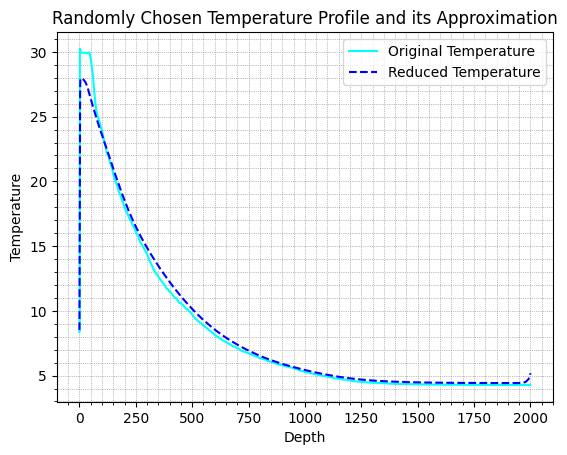

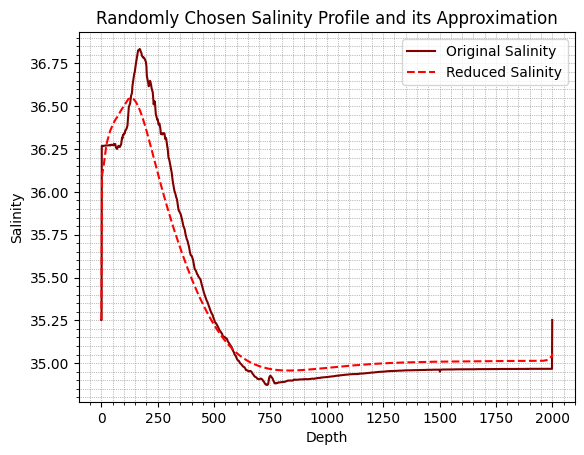

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from numpy import linalg

# Open the .mat file
file_name = "profiles.mat"
with h5py.File(file_name, 'r') as f:
    # Access relevant data (equivalent to MATLAB variables)
    temperature = f['TEMP'][()]
    salinity = f['SAL'][()]

# Handle NaN and inf values by replacing them with the mean of the profile
def replace_nan_inf(data):
    # Replace inf with NaN to handle them together
    data[np.isinf(data)] = np.nan
    # Get the mean of each profile ignoring NaNs
    means = np.nanmean(data, axis=1)
    # Replace NaNs with the mean of the corresponding profile
    inds = np.where(np.isnan(data))
    data[inds] = np.take(means, inds[0])
    return data

temperature = replace_nan_inf(temperature)
salinity = replace_nan_inf(salinity)

# Function to perform SVD and determine required singular values
def svd_analysis(data, threshold=0.95):
    U, S, VT = linalg.svd(data, full_matrices=False)
    explained_variance = np.cumsum(S**2) / np.sum(S**2)
    num_singular_values = np.searchsorted(explained_variance, threshold) + 1
    return U, S, VT, explained_variance, num_singular_values

# Perform SVD on temperature and salinity datasets
U_temp, S_temp, VT_temp, explained_var_temp, num_singular_values_temp = svd_analysis(temperature)
U_sal, S_sal, VT_sal, explained_var_sal, num_singular_values_sal = svd_analysis(salinity)

# Number of singular values required to capture 95% variance
print(f"Number of singular values for temperature to capture 95% variability: {num_singular_values_temp}")
print(f"Number of singular values for salinity to capture 95% variability: {num_singular_values_sal}")

# Percentage of variance explained by the first two singular values
variance_first_two_temp = explained_var_temp[1] * 100
variance_first_two_sal = explained_var_sal[1] * 100
print(f"Percentage of variance explained by the first two singular values (temperature): {variance_first_two_temp:.2f}%")
print(f"Percentage of variance explained by the first two singular values (salinity): {variance_first_two_sal:.2f}%")

# Function to reconstruct the data using the top 'num_singular_values' singular values
def reconstruct_data(U, S, VT, num_singular_values):
    U_reduced = U[:, :num_singular_values]
    S_reduced = S[:num_singular_values]
    VT_reduced = VT[:num_singular_values, :]
    return np.dot(U_reduced, np.diag(S_reduced) @ VT_reduced)

# Reconstruct the data using the required number of singular values
temperature_reduced = reconstruct_data(U_temp, S_temp, VT_temp, num_singular_values_temp)
salinity_reduced = reconstruct_data(U_sal, S_sal, VT_sal, num_singular_values_sal)

# Plot a randomly chosen profile and its approximation
random_index_temp = np.random.randint(0, temperature.shape[0])
plt.plot(temperature[random_index_temp], label='Original Temperature', color='cyan')
plt.plot(temperature_reduced[random_index_temp], label='Reduced Temperature', color='blue', linestyle='dashed')
plt.xlabel('Depth')
plt.ylabel('Temperature')
plt.title('Randomly Chosen Temperature Profile and its Approximation')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()

random_index_sal = np.random.randint(0, salinity.shape[0])
plt.plot(salinity[random_index_sal], label='Original Salinity', color='maroon')
plt.plot(salinity_reduced[random_index_sal], label='Reduced Salinity', color='red', linestyle='dashed')
plt.xlabel('Depth')
plt.ylabel('Salinity')
plt.title('Randomly Chosen Salinity Profile and its Approximation')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray')
plt.show()
